In [ ]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    "Compositional": Path("../logs/actvae/compositional"),
    "MDCEV": Path("../logs/actvae/mdcev"),
    "ActVAE": Path("../logs/actvae/cpvae"),
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "ActVAE-Cond": Path("../logs/actvae/conditional"),
    "ActVAE-Gen": Path("../logs/actvae/vae"),
    "LLM": Path("../logs/actvae/llm"),
    "LLM-ft": Path("../logs/actvae/llm_ft"),
}

# find data
target_schedules = pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    "~/Data/foundata/out/nts/2023/attributes_binned.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    if not versions:
        return path.name, path
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "eval" / "domains" / "distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "eval" / "domains" / "distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

/tmp/ipykernel_3548565/1973019654.py:29: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  target_attributes = pd.read_csv(


In [29]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/actvae/compositional/seed_11111
Loading synthetic attributes from ../logs/actvae/mdcev/seed_11111
Loading synthetic attributes from ../logs/actvae/cpvae/cpvae_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/conditional/conditional_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/vae/vae_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/llm/llm/version_0
Loading synthetic attributes from ../logs/actvae/llm_ft/llm_ft/version_0


In [34]:
def build_distance_tables(batch_paths):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "domains" / "distances.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths)
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df.T

\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{MDCEV} & \multicolumn{2}{r}{ActVAE} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{LLM} & \multicolumn{2}{r}{LLM-ft} \\
 & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
participations & 0.396 & 0.000 & 0.343 & 0.001 & 0.090 & 0.000 & 0.402 & 0.000 & 0.117 & 0.000 & 0.393 & NaN & 0.304 & NaN \\
transitions & 0.021 & 0.000 & 0.023 & 0.000 & 0.005 & 0.000 & 0.020 & 0.000 & 0.007 & 0.000 & 0.021 & NaN & 0.016 & NaN \\
timing & 0.107 & 0.000 & 0.160 & 0.000 & 0.053 & 0.000 & 0.200 & 0.000 & 0.057 & 0.000 & 0.224 & NaN & 0.276 & NaN \\
feasibility & 0.000 & 0.000 & 0.018 & 0.000 & 0.012 & 0.000 & 0.000 & 0.000 & 0.015 & 0.000 & 0.064 & NaN & 0.000 & NaN \\
creativity & 0.128 & 0.000 & 0.078 & 0.000 & 0.031 & 0.000 & 0.264 & 0.000 & 0.030 & 0.000 & 0.551 &

domain               creativity   feasibility  participations        timing  \
Compositional EMD  1.282280e-01  3.432268e-06    3.956162e-01  1.072920e-01   
              var  3.183835e-07  5.890232e-11    9.433279e-07  1.152812e-07   
MDCEV         EMD  7.779993e-02  1.841553e-02    3.430841e-01  1.600027e-01   
              var  3.198163e-04  6.708842e-06    1.174318e-03  9.904376e-05   
ActVAE        EMD  3.132685e-02  1.197829e-02    8.999066e-02  5.336859e-02   
              var  1.253449e-06  1.174170e-05    1.312048e-04  2.787411e-06   
ActVAE-Cond   EMD  2.638871e-01  1.134657e-04    4.021561e-01  1.998013e-01   
              var  2.661078e-05  6.437238e-08    9.148612e-06  1.141230e-04   
ActVAE-Gen    EMD  3.013504e-02  1.504700e-02    1.174426e-01  5.651219e-02   
              var  5.550655e-07  7.636629e-05    6.505279e-06  3.933448e-06   
LLM           EMD  5.507323e-01  6.443159e-02    3.929779e-01  2.244957e-01   
              var           NaN           NaN             NaN           NaN   
LLM-ft        EMD  2.827973e-01  0.000000e+00    3.039438e-01  2.756872e-01   
              var           NaN           NaN             NaN           NaN   

domain              transitions  
Compositional EMD  2.086078e-02  
              var  8.698017e-10  
MDCEV         EMD  2.334560e-02  
              var  2.549537e-06  
ActVAE        EMD  5.313093e-03  
              var  4.221656e-07  
ActVAE-Cond   EMD  2.039167e-02  
              var  3.442013e-07  
ActVAE-Gen    EMD  6.664332e-03  
              var  1.228678e-07  
LLM           EMD  2.098904e-02  
              var           NaN  
LLM-ft        EMD  1.630346e-02  
              var           NaN

In [ ]:
def group_tables(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "groups" / "distances.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / "eval" / "groups" / "descriptions.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

Compositional ['seed_11111', 'seed_33333', 'seed_22222', 'seed_44444', 'seed_55555']
MDCEV ['seed_11111', 'seed_33333', 'seed_22222', 'seed_44444', 'seed_55555']
ActVAE ['cpvae_nrun3', 'cpvae_nrun4', 'cpvae_nrun1', 'cpvae_nrun2', 'cpvae_nrun0']
ActVAE-Cond ['conditional_nrun3', 'conditional_nrun1', 'conditional_nrun4', 'conditional_nrun2', 'conditional_nrun0']
ActVAE-Gen ['vae_nrun4', 'vae_nrun1', 'vae_nrun3', 'vae_nrun0', 'vae_nrun2']
LLM ['llm']
LLM-ft ['llm_ft']
\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{MDCEV} & \multicolumn{2}{r}{ActVAE} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{LLM} & \multicolumn{2}{r}{LLM-ft} \\
 & mean & var & mean & var & mean & var & mean & var & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
lengths & 0.933 & 0.000 & 0.813 & 0.008 & 0.213 & 0.001 & 0.997 & 0.000 & 0.274 & 0.000 & 0.910 & NaN & 0.664 & 

In [ ]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(
            path / "eval" / "features" / "descriptions.csv"
        ).set_index(["domain", "feature", "segment"])
        distances = pd.read_csv(
            path / "eval" / "features" / "distances.csv"
        ).set_index(["domain", "feature", "segment"])
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{MDCEV} & \multicolumn{2}{r}{ActVAE} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{LLM} & \multicolumn{2}{r}{LLM-ft} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean & EMD & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.931 & 3.078 & 0.933 & 4.569 & 0.813 & 3.905 & 0.213 & 3.012 & 0.997 & 3.863 & 0.274 & 3.356 & 0.910 & 3.804 & 0.664 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{MDCEV} & \multicolumn{2}{r}{ActVAE} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{LLM} & \multicolumn{2}{r}{LLM-ft} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean 

Observed Compositional            \
                                                               mean       EMD   
feature                 segment                                                 
lengths                 sequence lengths     3.930729      3.077903  0.933315   
pair participation rate home+home            1.055170      0.890058  0.188556   
                        other+other          0.086897      0.003071  0.084074   
                        home+other           0.084394      0.003071  0.081553   
                        escort+escort        0.076145      0.003282  0.072797   
                        escort+home          0.073060      0.003282  0.069712   
                        shop+shop            0.034124      0.002873  0.031334   
                        home+shop            0.033472      0.002873  0.030686   
                        visit+visit          0.013572      0.002968  0.010699   
                        home+visit           0.013343      0.002968  0.010467   
                        home+work            0.010311      0.000000  0.010253   
                        work+work            0.010311      0.000000  0.010253   
                        escort+other         0.004759      0.000000  0.004741   
                        other+shop           0.002820      0.000000  0.002814   
                        escort+shop          0.002203      0.000000  0.002190   
                        other+visit          0.001833      0.000000  0.001858   
                        home+medical         0.001622      0.003243  0.001664   
                        medical+medical      0.001622      0.003243  0.001664   
                        education+education  0.001128      0.000000  0.001105   
                        education+home       0.001128      0.000000  0.001105   
                        shop+visit           0.000969      0.000000  0.000968   
participation rate      home                 2.325642      1.988358  0.389513   
                        other                0.530617      0.057792  0.475452   
                        shop                 0.297864      0.058362  0.241338   
                        escort               0.257676      0.058151  0.200504   
                        work                 0.254644      0.400319  0.182084   
                        visit                0.129799      0.058634  0.072799   
                        education            0.091162      0.398155  0.309276   
                        medical              0.043325      0.058137  0.019240   

                                                MDCEV              ActVAE  \
                                                 mean       EMD      mean   
feature                 segment                                             
lengths                 sequence lengths     4.568835  0.812861  3.905089   
pair participation rate home+home            1.033755  0.067852  1.050882   
                        other+other          0.046954  0.042369  0.091911   
                        home+other           0.046954  0.039897  0.086933   
                        escort+escort        0.054373  0.040248  0.060245   
                        escort+home          0.054373  0.037616  0.057820   
                        shop+shop            0.071494  0.037960  0.043664   
                        home+shop            0.071494  0.037535  0.042187   
                        visit+visit          0.003916  0.009836  0.010238   
                        home+visit           0.003916  0.009612  0.010100   
                        home+work            0.000000  0.010317  0.014862   
                        work+work            0.000000  0.010317  0.014905   
                        escort+other         0.000879  0.003938  0.004273   
                        other+shop           0.004111  0.001441  0.005041   
                        escort+shop          0.001504  0.000992  0.002277   
                        other+visit          0.000203  0.001680  0

In [ ]:
def build_labels_table(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "eval" / "domains_by_attribute" / "distances.csv"
        ).set_index(["domain", "label"])

        columns = set(label_distances.columns)
        # unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "cat",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns].groupby(["domain", "label"]).mean()
        )

        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)
        descriptions_combined[name, "var"] = label_distances.var(axis=1)

    # descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    order = list(descriptions_combined.columns)

    index = ["participations", "transitions", "timing"]

    return descriptions_combined.loc[index, order]


table = build_labels_table(batch_paths)
print(table.to_latex(float_format="{:.3f}".format))


table

\begin{tabular}{llrrrrrrrrrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{MDCEV} & \multicolumn{2}{r}{ActVAE} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{LLM} & \multicolumn{2}{r}{LLM-ft} \\
 &  & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var & EMD & var \\
domain & label &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{participations} & access_egress_distance & 0.365 & 0.000 & 0.312 & 0.001 & 0.051 & 0.000 & 0.370 & 0.000 & 0.088 & 0.000 & 0.298 & NaN & 0.200 & NaN \\
 & age & 0.368 & 0.000 & 0.312 & 0.001 & 0.066 & 0.000 & 0.377 & 0.000 & 0.109 & 0.000 & 0.291 & NaN & 0.187 & NaN \\
 & day & 0.365 & 0.000 & 0.307 & 0.001 & 0.047 & 0.000 & 0.372 & 0.000 & 0.066 & 0.000 & 0.278 & NaN & 0.182 & NaN \\
 & employment & 0.370 & 0.000 & 0.319 & 0.001 & 0.070 & 0.000 & 0.379 & 0.000 & 0.103 & 0.000 & 0.477 & NaN & 0.390 & NaN \\
 & hh_income & 0.365 & 0.000 & 0.307 & 0.00

Compositional                   MDCEV  \
                                                EMD           var       EMD   
domain         label                                                          
participations access_egress_distance      0.365437  1.012284e-06  0.311844   
               age                         0.367619  1.115196e-06  0.311657   
               day                         0.365291  9.792667e-07  0.307097   
               employment                  0.369662  9.354995e-07  0.319284   
               hh_income                   0.365288  9.818635e-07  0.307136   
               hh_zone                     0.365287  9.800573e-07  0.307122   
               sex                         0.365287  9.800573e-07  0.306024   
               vehicles                    0.601079  6.136530e-07  0.575472   
transitions    access_egress_distance      0.020669  7.711673e-10  0.023015   
               age                         0.021308  1.535148e-09  0.023481   
               day                         0.020696  6.402485e-10  0.022500   
               employment                  0.021547  1.495271e-09  0.023896   
               hh_income                   0.020636  9.219707e-10  0.022536   
               hh_zone                     0.020602  1.146164e-09  0.022481   
               sex                         0.020576  1.164646e-09  0.022363   
               vehicles                    0.020852  4.590155e-10  0.026637   
timing         access_egress_distance      0.077138  8.218594e-08  0.136136   
               age                         0.097192  3.535750e-07  0.146629   
               day                         0.077142  7.758334e-08  0.134632   
               employment                  0.079200  8.799104e-08  0.146454   
               hh_income                   0.077031  1.095274e-07  0.135657   
               hh_zone                     0.075925  3.785930e-07  0.133318   
               sex                         0.075100  1.618846e-07  0.133762   
               vehicles                    0.299621  7.849131e-08  0.313452   

                                                   ActVAE                \
                                            var       EMD           var   
domain         label                                                      
participations access_egress_distance  0.001218  0.050725  1.644997e-04   
               age                     0.001287  0.065566  1.351714e-04   
               day                     0.001271  0.046830  1.378676e-04   
               employment              0.001324  0.069591  1.852481e-04   
               hh_income               0.001287  0.045599  1.189788e-04   
               hh_zone                 0.001252  0.044753  1.125166e-04   
               sex                     0.001278  0.043583  1.420025e-04   
               vehicles                0.000597  0.353304  8.795880e-05   
transitions    access_egress_distance  0.000003  0.004470  4.464527e-07   
               age                     0.000003  0.007427  9.089391e-07   
               day                     0.000003  0.004282  2.135610e-07   
               employment              0.000004  0.007458  1.285238e-06   
               hh_income               0.000003  0.003955  3.123258e-07   
               hh_zone                 0.000003  0.003707  3.859091e-07   
               sex                     0.000003  0.003635  4.207645e-07   
               vehicles                0.000002  0.007570  4.092687e-07   
timing         access_egress_distance  0.000096  0.025575  2.019643e-06   
               age                     0.000095  0.038036  7.629061e-06   
               day                     0.000077  0.025704  2.921958e-06   
               employment              0.000086  0.033475  7.108914e-06   
               hh_income               0.000091  0.024533  2.134366e-06   
               hh_zone                 0.000077  0.023784  1.564375e-06   
               sex           

In [43]:
# def build_all_description_tables_subs_fixed(batch_paths, on="work_status"):
#     descriptions_combined = pd.DataFrame()

#     for name, path in batch_paths.items():
#         label_descriptions = pd.read_csv(
#             path / "eval" / "features_by_attribute" / "descriptions.csv"
#         )
#         label_distances = pd.read_csv(
#             path / "eval" / "features_by_category" / "distances.csv"
#         )
#         descriptions = pd.read_csv(
#             path / "eval" / "features_by_category" / "descriptions.csv"
#         )

#         columns = set(label_descriptions.columns)
#         columns = list(
#             columns
#             - set(
#                 [
#                     "label",
#                     "cat",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#         )

#         distances = (
#             label_distances[columns]
#             .loc[label_distances.label == on]
#             .set_index(["domain", "feature", "segment"])
#             .groupby(["domain", "feature", "segment"])
#             .mean()
#         ).reset_index()
#         descriptions["label"] = on
#         distances["label"] = on
#         descriptions["cat"] = "combined"
#         distances["cat"] = "combined"

#         columns = set(distances.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )
#         distances = distances[columns]

#         label_descriptions = pd.concat((label_descriptions, descriptions))
#         label_distances = pd.concat((label_distances, distances))

#         label_descriptions = (
#             label_descriptions.loc[label_descriptions.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )
#         label_distances = (
#             label_distances.loc[label_distances.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )

#         columns = set(label_descriptions.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )

#         observed = label_descriptions["observed"]
#         unit = label_descriptions["unit"]

#         label_descriptions = label_descriptions[columns]
#         label_distances = label_distances[columns]

#         descriptions_combined[name, "mean"] = label_descriptions.mean(axis=1)
#         descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)

#     descriptions_combined["Observed", ""] = observed
#     descriptions_combined["Description", ""] = unit
#     descriptions_combined.columns = pd.MultiIndex.from_tuples(
#         descriptions_combined.columns
#     )
#     descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
#         ["domain", "feature", "segment"], group_keys=False
#     ).transform("max")
#     descriptions_combined = descriptions_combined.sort_values(
#         ["maxi"], ascending=False
#     ).drop(columns=["maxi"])

#     descriptions_combined = descriptions_combined.groupby(
#         ["domain", "feature"], group_keys=False
#     ).apply(lambda x: x.head(1000))

#     order = list(descriptions_combined.columns)
#     order.pop(order.index(("Observed", "")))
#     order = [("Observed", "")] + order

#     index = [
#         "participations",
#         "transitions",
#         "timing",
#         "feasibility",
#         "creativity",
#     ]

#     return descriptions_combined.loc[index, order]


# table = build_all_description_tables_subs_fixed(batch_paths)

# p = table.loc["participations"]
# for name in ["lengths", "participation rate"]:
#     print(name)
#     pp = p.loc[name]
#     pp.loc[:, "Description"] = "rate"
#     print(pp.to_latex(float_format="{:.3f}".format))
#     print()

In [44]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="gender")
# t = table.loc["transitions"]
# acts = [
#     "home>other",
#     "home>work",
#     "home>education",
#     "home>shop",
#     "home>visit",
#     "home>escort",
#     "home>medical",
# ]
# data = []
# for act in acts:
#     tt = t.loc["2-gram"]
#     tt.loc[:, "Description"] = "rate"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))
# data

In [45]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="car_access")
# t = table.loc["timing"]
# acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
# data = []
# for act in acts:
#     tt = t.loc["start times"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

# data = []
# for act in acts:
#     tt = t.loc["durations"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

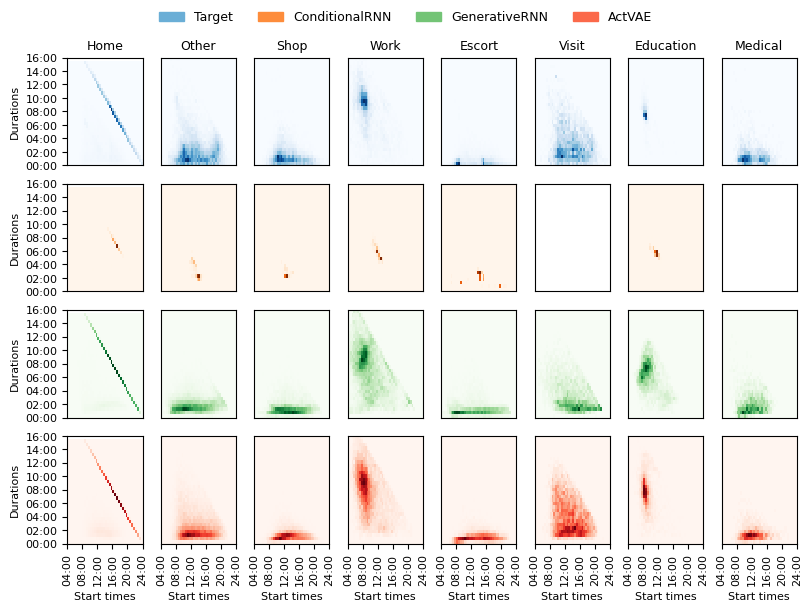

In [18]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(8, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

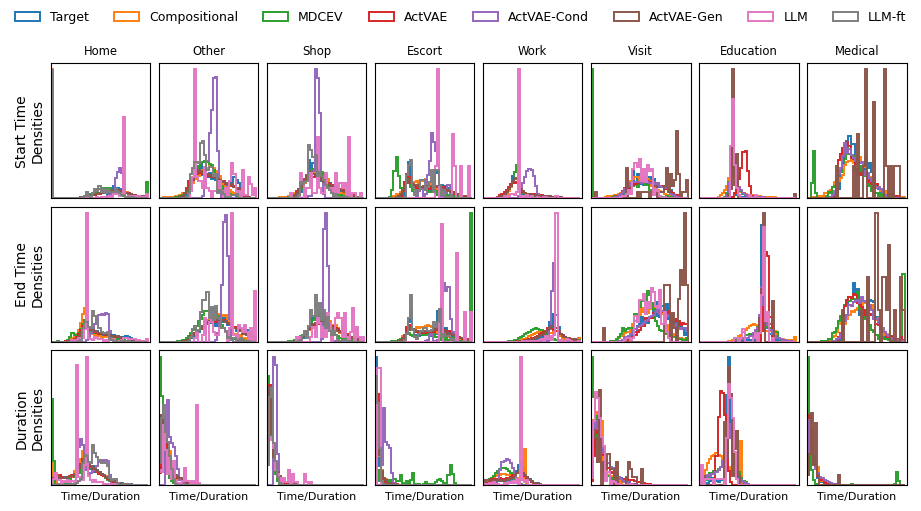

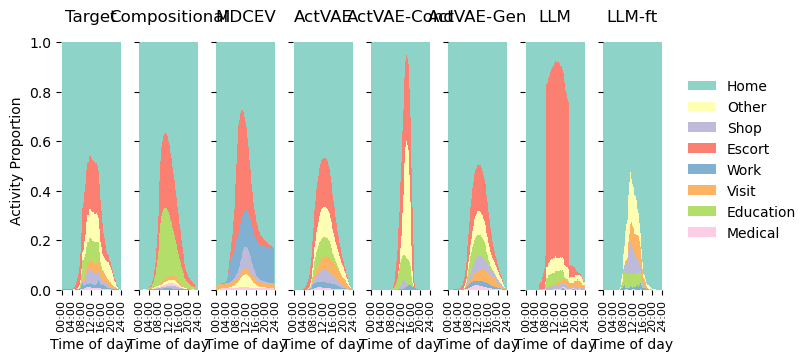

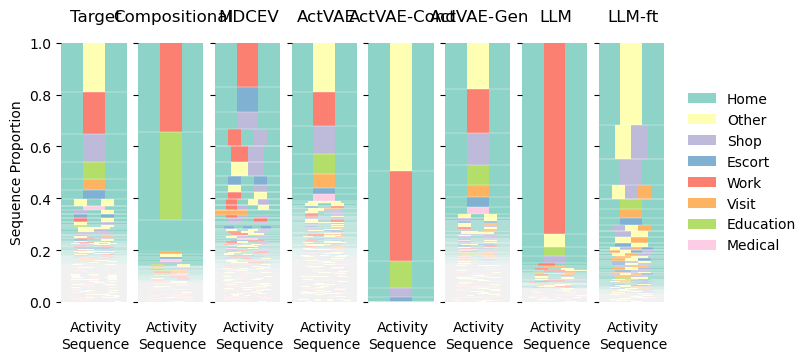

In [46]:
from acteval.describe.frequency import frequency_plots
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.describe.transitions import sequence_prob_plot

fig = times_distributions_plot(
    target_schedules, schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)

In [47]:
# import random

# from pam.core import Household, Person
# from pam.plot.plans import plot_household

# from caveat.data.utils import trace_to_pam


# def stretch(schedules):
#     return schedules.groupby(schedules.pid).apply(stretcher)


# def stretcher(schedule):
#     duration = schedule.duration.sum()
#     if duration != 1440:
#         a = 1440 / duration
#         schedule.duration = (schedule.duration * a).astype(int)
#         accumulated = list(schedule.duration.cumsum())
#         schedule.start = [0] + accumulated[:-1]
#         schedule.end = accumulated
#     return schedule


# def trim(schedules):
#     schedules[schedules.end > 1440] = 1440
#     schedules[schedules.start > 1440] = 1440
#     schedules.duration = schedules.end - schedules.start
#     schedules = schedules[schedules.duration > 0]
#     return schedules


# def pad(schedules):
#     return (
#         schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
#     )


# def padder(schedule):
#     if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
#         pid = schedule.pid.iloc[0]
#         schedule = pd.concat(
#             [
#                 schedule,
#                 DataFrame(
#                     {
#                         "pid": pid,
#                         "start": schedule.end.iloc[-1],
#                         "end": 1440,
#                         "duration": 1440 - schedule.end.iloc[-1],
#                         "act": "home",
#                     },
#                     index=[0],
#                 ),
#             ]
#         )
#     elif schedule.end.iloc[-1] < 1440:
#         schedule.end.iloc[-1] = 1440
#         schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
#     return schedule


# def plot_schedules(schedules, **kwargs):
#     cmap = {
#         "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
#         "other": (1.0, 1.0, 0.7019607843137254),
#         "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
#         "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
#         "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
#         "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
#         "education": (
#             0.7019607843137254,
#             0.8705882352941177,
#             0.4117647058823529,
#         ),
#         "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
#         "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
#     }
#     cmap = {n.title(): c for n, c in cmap.items()}

#     hh = Household("")
#     pids = schedules.pid
#     selected = random.sample(list(pids), 8)
#     for i, pid in enumerate(selected):
#         person = Person(pid)
#         plan = schedules[schedules.pid == pid]
#         plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
#         mapping = {a: a for a in plan.act}

#         trace = [
#             (row.act, row.start, row.end, row.duration)
#             for i, row in plan.iterrows()
#         ]
#         plan = trace_to_pam(trace, mapping)

#         person = Person(i)
#         person.plan = plan
#         hh.add(person)

#     plot_household(hh, cmap=cmap, width=25)

In [48]:
# plot_schedules(target_schedules)

In [49]:
# p = batch_paths["ActVAE"]
# examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
# plot_schedules(examples)

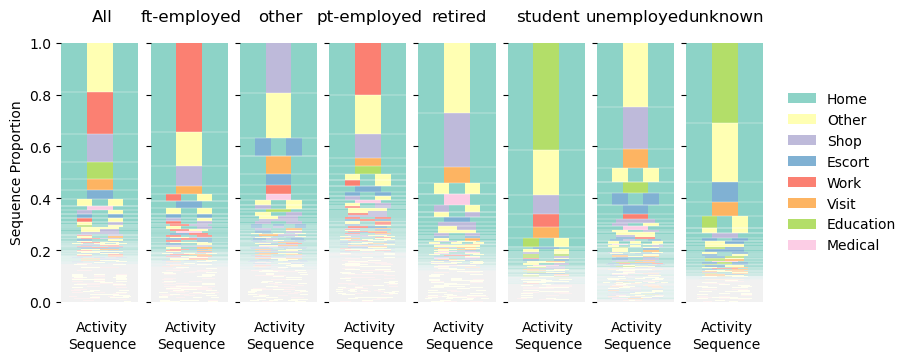

In [51]:
splits = split_on(target_schedules, target_attributes, by="employment")
fig = sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

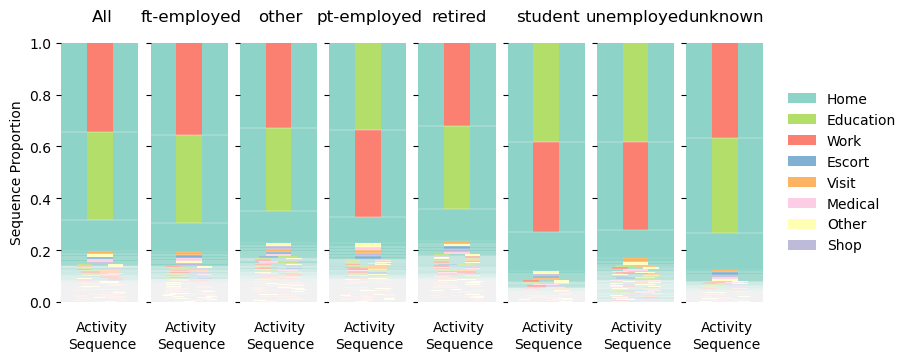

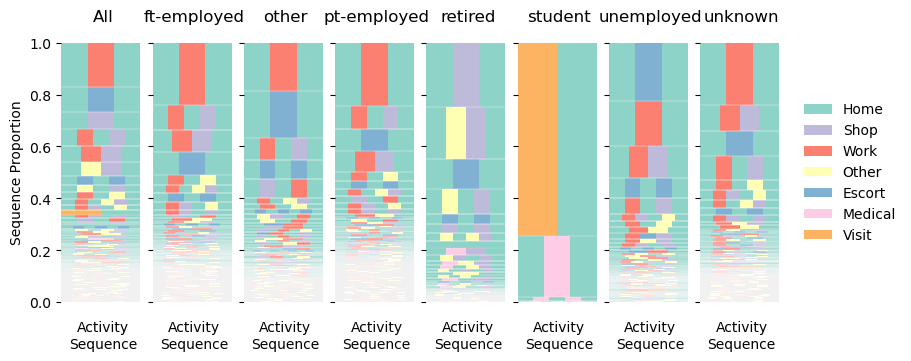

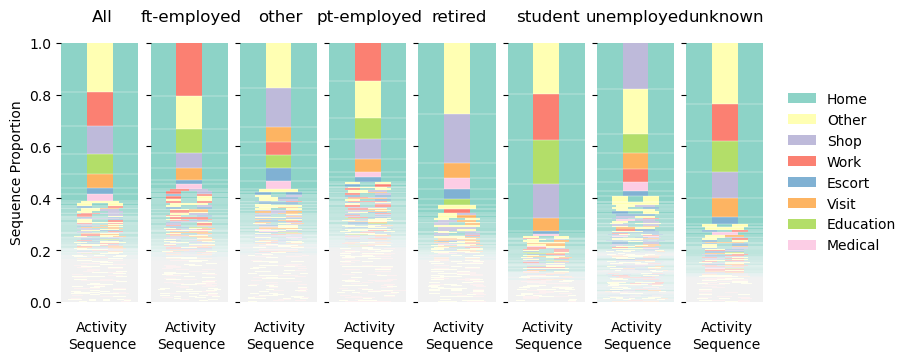

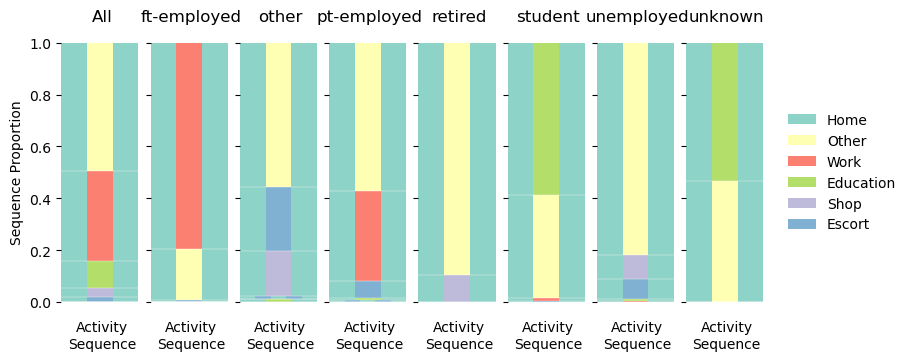

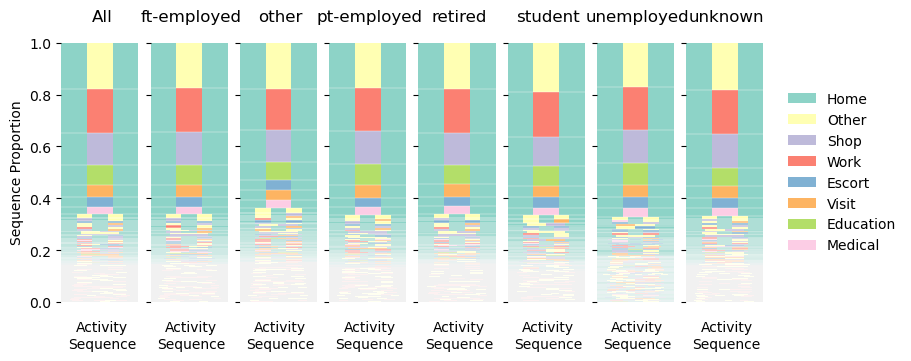

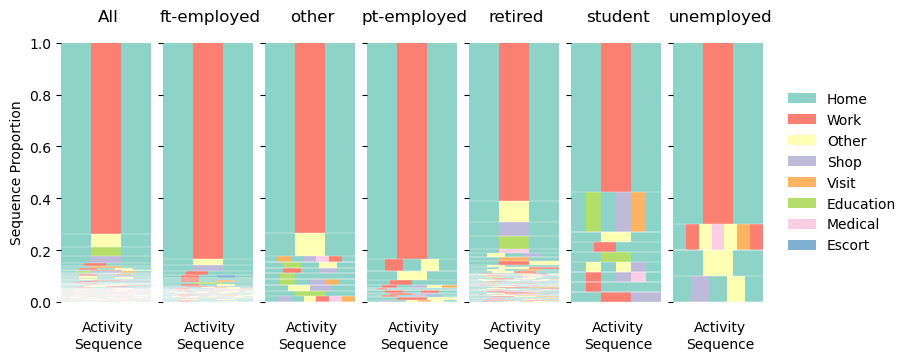

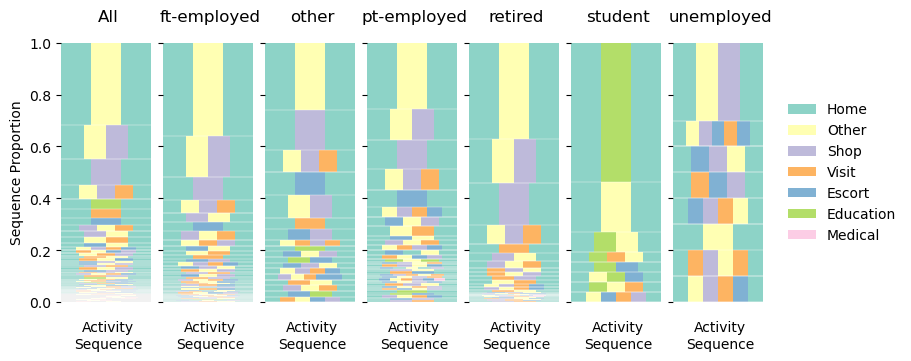

In [52]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k], by="employment")
    fig = sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

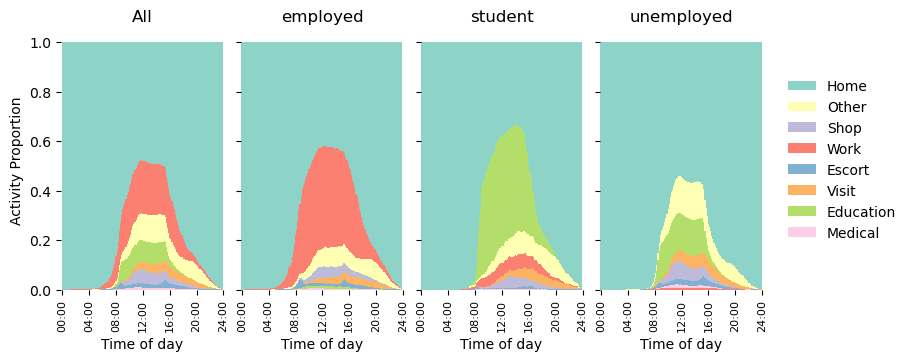

In [25]:
splits = split_on(target_schedules, target_attributes)
fig = frequency_plots(
    target_schedules, splits, observed_title="All", color=cmap, figsize=(9, 3.5)
)

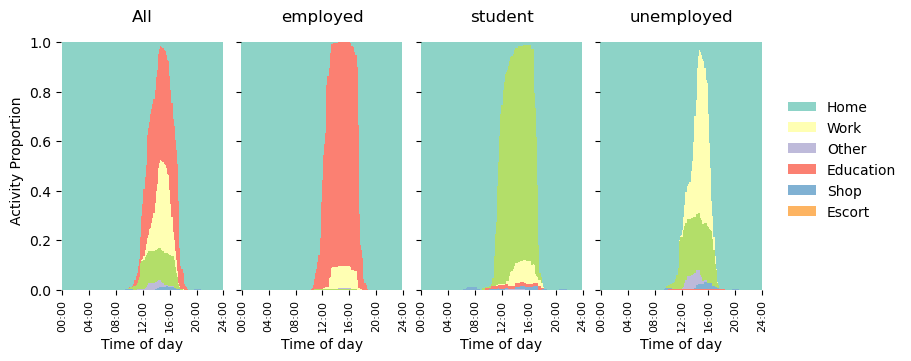

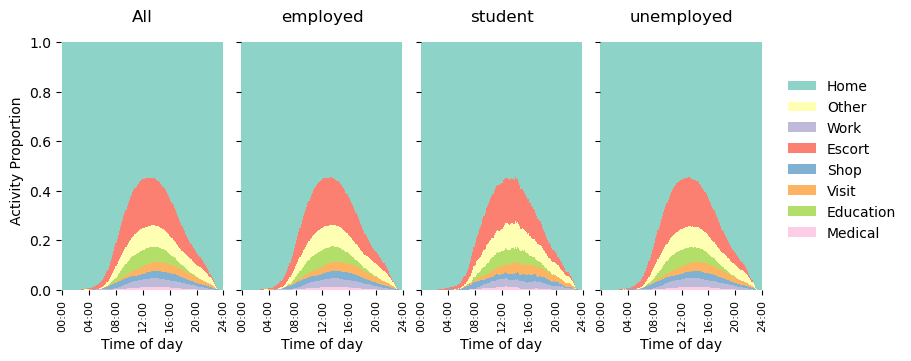

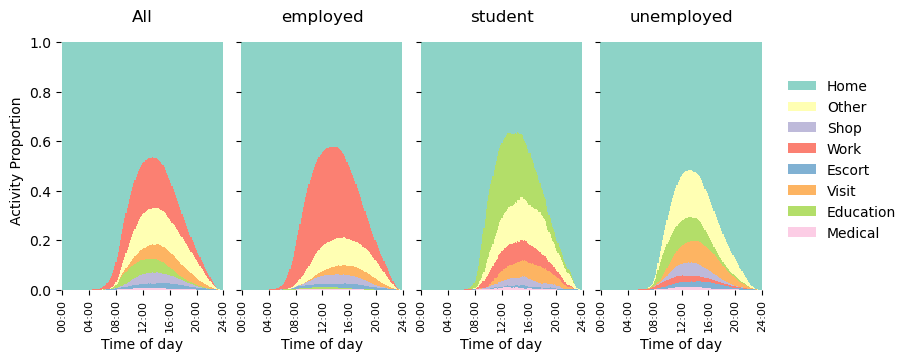

In [ ]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = frequency_plots(
        scheds, splits, observed_title="All", color=cmap, figsize=(9, 3.5)
    )

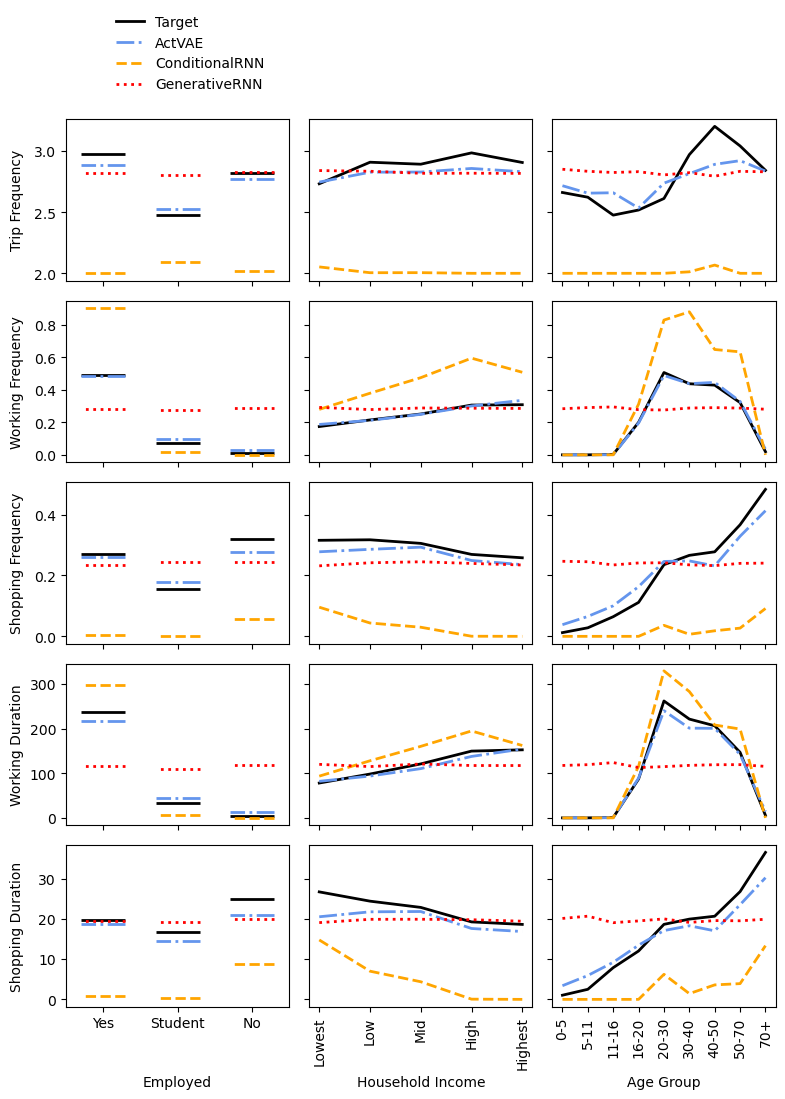

In [ ]:
def duration(schedules, act="work"):
    n = schedules.pid.nunique()
    return schedules[schedules.act == act].duration.sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    age_order = [
        "<5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    ages = [
        "0-5",
        "5-11",
        "11-16",
        "16-20",
        "20-30",
        "30-40",
        "40-50",
        "50-70",
        "70+",
    ]
    colours = [
        "black",
        "cornflowerblue",
        "orange",
        "red",
        "purple",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "-.", "--", ":", ":", ".-"]

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by="work_status")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="work_status")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=2,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_xlim(-0.5, 2.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks([0, 1, 2], ["Yes", "Student", "No"], rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by="income")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="income")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [1, 2, 3, 4, 5],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by="age_group")
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by="age_group")
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=2)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [28]:
# structure ablation
ablations = {
    "actvae": pd.read_csv(Path("../logs/TRB/cvae/domain_distances_subs.csv"))
    .set_index("domain")
    .drop("observed", axis=1)
    .mean(axis=1)
}

abs = ["aaaa", "cncn", "deep", "nana", "nnan", "no_weighting", "shallow"]

for p in abs:
    path = Path(f"../logs/TRB/ablation/{p}/domain_distances_subs.csv")
    ablations[p] = (
        pd.read_csv(path)
        .set_index("domain")
        .drop("observed", axis=1)
        .mean(axis=1)
    )
ablations = pd.DataFrame(ablations).T

print(
    ablations[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
ablations

\begin{tabular}{lrrrrr}
\toprule
domain & participations & transitions & timing & feasibility & creativity \\
\midrule
actvae & 0.072 & 0.005 & 0.029 & 0.030 & 0.012 \\
aaaa & 0.098 & 0.007 & 0.050 & 0.022 & 0.026 \\
cncn & 0.069 & 0.005 & 0.029 & 0.020 & 0.011 \\
deep & 0.069 & 0.005 & 0.028 & 0.022 & 0.010 \\
nana & 0.090 & 0.007 & 0.042 & 0.020 & 0.013 \\
nnan & 0.105 & 0.008 & 0.042 & 0.026 & 0.011 \\
no_weighting & 0.076 & 0.005 & 0.027 & 0.018 & 0.012 \\
shallow & 0.077 & 0.005 & 0.029 & 0.022 & 0.010 \\
\bottomrule
\end{tabular}



domain,creativity,feasibility,participations,timing,transitions
actvae,0.011527,0.030284,0.071619,0.029020,0.005164
aaaa,0.025996,0.022292,0.098499,0.050291,0.006860
cncn,0.011446,0.019750,0.069085,0.028891,0.004824
deep,0.009764,0.021940,0.069095,0.028331,0.004528
nana,0.012853,0.020339,0.090346,0.041734,0.006634
nnan,0.011419,0.025651,0.105325,0.041775,0.008303
no_weighting,0.011894,0.018100,0.076373,0.026603,0.004820
shallow,0.010450,0.021882,0.077198,0.028724,0.004870


In [29]:
diffs = ablations[
    ["participations", "transitions", "timing", "feasibility", "creativity"]
]
for a in abs:
    diffs.loc[a] = diffs.loc[a] - diffs.loc["actvae"]
print(
    diffs.T[
        ["actvae", "no_weighting", "cncn", "nana", "nnan", "aaaa"]
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrrr}
\toprule
 & actvae & no_weighting & cncn & nana & nnan & aaaa \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.072 & 0.005 & -0.003 & 0.019 & 0.034 & 0.027 \\
transitions & 0.005 & -0.000 & -0.000 & 0.001 & 0.003 & 0.002 \\
timing & 0.029 & -0.002 & -0.000 & 0.013 & 0.013 & 0.021 \\
feasibility & 0.030 & -0.012 & -0.011 & -0.010 & -0.005 & -0.008 \\
creativity & 0.012 & 0.000 & -0.000 & 0.001 & -0.000 & 0.014 \\
\bottomrule
\end{tabular}



In [30]:
structure_schedules = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
}
structure_attributes = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_attributes.csv"
    )
}
for name in abs:
    structure_schedules[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
    structure_attributes[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_attributes.csv"
    )

ValueError: Do not know how to convert '.-' to dashes

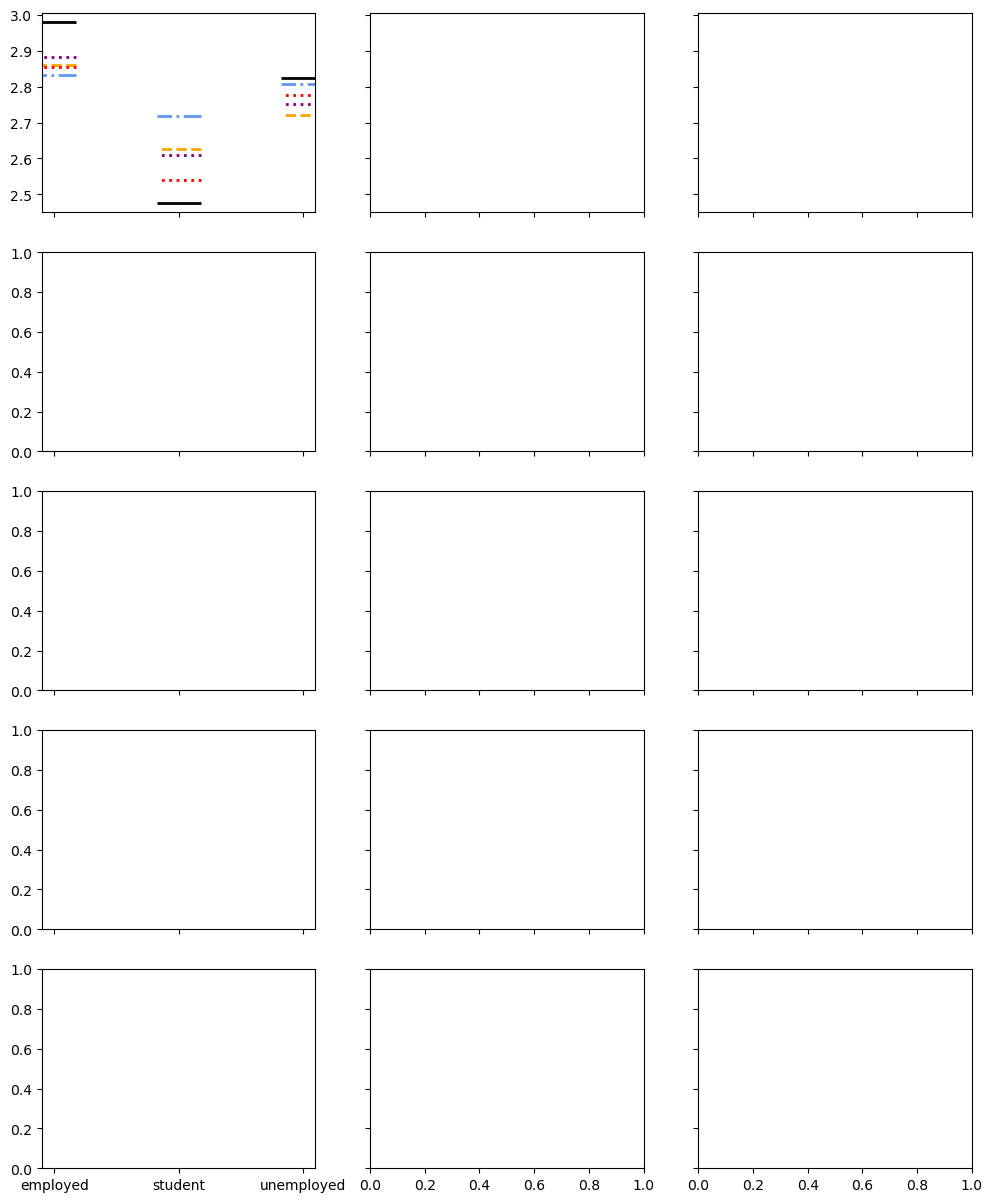

In [31]:
plot_conditionals(
    structure_schedules,
    structure_attributes,
    target_schedules,
    target_attributes,
    figsize=(12, 15),
)

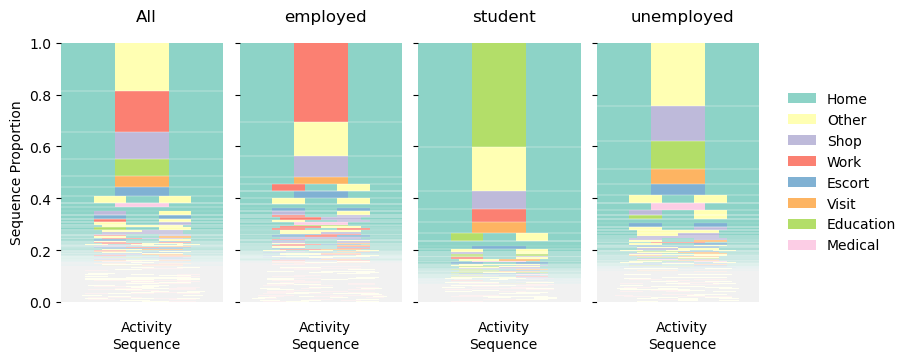

In [ ]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

actvae
aaaa
cncn


KeyboardInterrupt: 

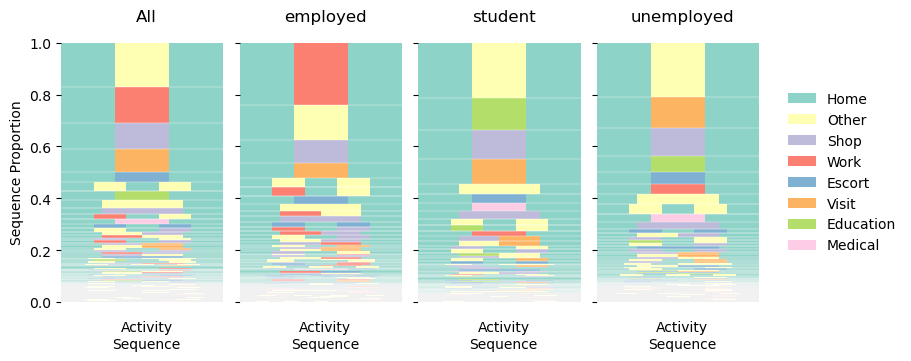

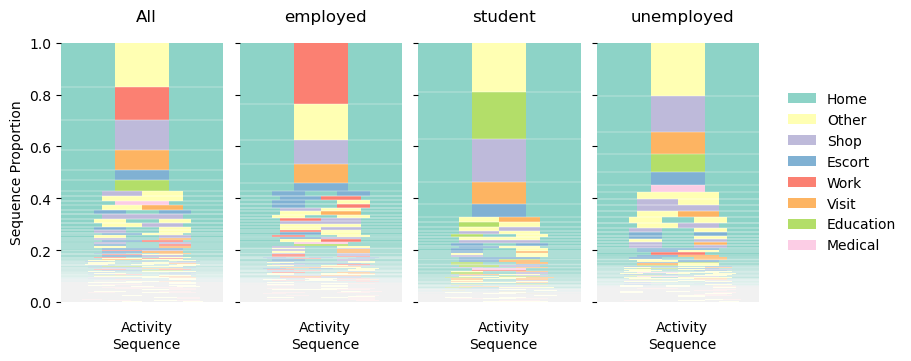

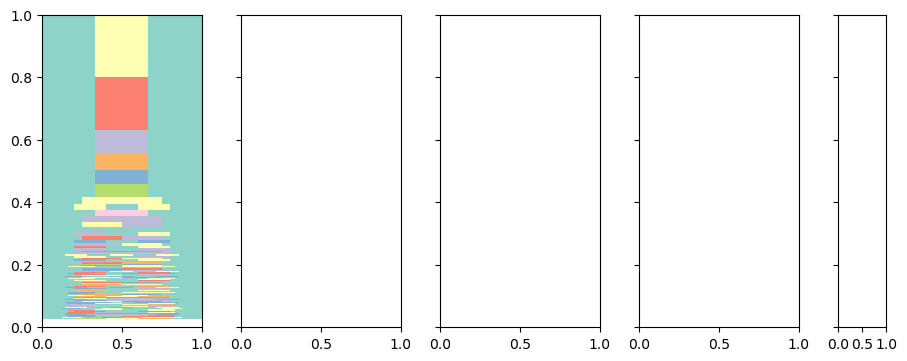

In [ ]:
for k, scheds in structure_schedules.items():
    print(k)
    splits = split_on(scheds, structure_attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

In [ ]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nomis_ages_2023.csv")),
    2030: pd.read_csv(Path("../tmp/nomis_ages_2030.csv")),
    2040: pd.read_csv(Path("../tmp/nomis_ages_2040.csv")),
    2050: pd.read_csv(Path("../tmp/nomis_ages_2050.csv")),
}
demographics = pd.DataFrame(
    {year: a.age_group.value_counts() for year, a in attributes.items()}
).loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
print(demographics.sum(axis=0))
demographics

2023    665724
2030    699305
2040    728662
2050    752774
dtype: int64


,2023,2030,2040,2050
age_group,,,,
<5,34326,33646,34374,34675
5-11,37721,34636,34683,35636
11-16,40014,38047,35112,35843
16-20,39084,41337,36695,36744
20-30,84624,91031,91666,84083
30-40,91600,97774,100502,101176
40-50,82651,92829,100742,103549
50-70,163726,166425,169439,187201
70+,91978,103580,125449,133867


In [ ]:
# add zero row at top, i.e:
#     0, 0, 0, 0, 0
new_row = pd.DataFrame({year: 0 for year in demographics.columns}, index=["0"])
demographics = pd.concat([new_row, demographics])
demographics

,2023,2030,2040,2050
0,0,0,0,0
<5,34326,33646,34374,34675
5-11,37721,34636,34683,35636
11-16,40014,38047,35112,35843
16-20,39084,41337,36695,36744
20-30,84624,91031,91666,84083
30-40,91600,97774,100502,101176
40-50,82651,92829,100742,103549
50-70,163726,166425,169439,187201
70+,91978,103580,125449,133867


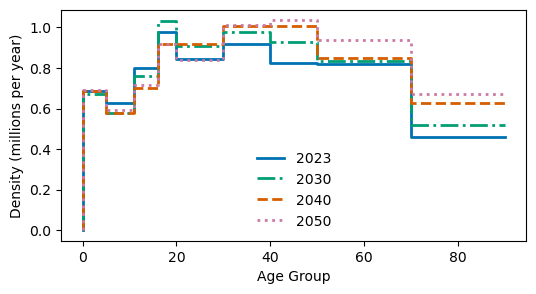

In [ ]:
scaled = demographics * 100 / 1000000

scaled["duration"] = [1, 5, 6, 5, 4, 10, 10, 10, 20, 20]
for year in [2023, 2030, 2040, 2050]:
    scaled[year] = scaled[year] / scaled.duration
scaled.duration = scaled.duration.cumsum() - 1

fig, ax = plt.subplots(figsize=(6, 3))

# Use a colorblind-friendly palette from matplotlib
colors = [
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
]  # blue, green, orange, purple
linestyles = ["-", "-.", "--", ":"]

for year, c, linestyle in zip([2023, 2030, 2040, 2050], colors, linestyles):
    ax.step(
        scaled.duration,
        scaled[year],
        label=str(year),
        color=c,
        linestyle=linestyle,
        linewidth=2,
    )
# for y in scaled.index:
#     ax.axhline(y, color="lightgrey", linestyle="--", linewidth=0.5, zorder=0)

ax.set_ylabel("Density (millions per year)")
ax.set_xlabel("Age Group")
ax.legend(scaled.columns, loc="lower center", frameon=False, title_fontsize=12)
# ax.set_xlim(0, 20)

In [ ]:
scaled

,2023,2030,2040,2050,duration
0,0.000000,0.000000,0.000000,0.000000,0
<5,0.686520,0.672920,0.687480,0.693500,5
5-11,0.628683,0.577267,0.578050,0.593933,11
11-16,0.800280,0.760940,0.702240,0.716860,16
16-20,0.977100,1.033425,0.917375,0.918600,20
20-30,0.846240,0.910310,0.916660,0.840830,30
30-40,0.916000,0.977740,1.005020,1.011760,40
40-50,0.826510,0.928290,1.007420,1.035490,50
50-70,0.818630,0.832125,0.847195,0.936005,70
70+,0.459890,0.517900,0.627245,0.669335,90


In [ ]:
aged_schedule_paths = {
    n[1:]: Path("../logs/TRB/cvae_nomis_scenario") / n / "version_1"
    for n in ["a2023", "a2030", "a2040", "a2050"]
}
age_schedules = {
    n: pd.read_csv(p / "synthetic_schedules.csv")
    for n, p in aged_schedule_paths.items()
}
age_attributes = {
    n: pd.read_csv(p / "synthetic_attributes.csv")
    for n, p in aged_schedule_paths.items()
}
age_target = age_schedules.pop("2023")
age_attributes_target = age_attributes.pop("2023")

KeyboardInterrupt: 

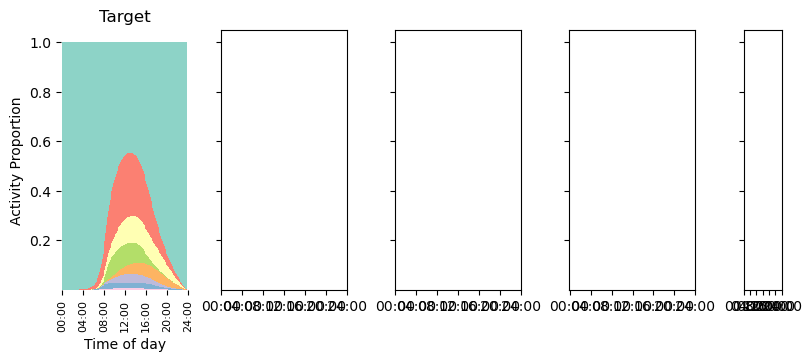

In [ ]:
fig = frequency_plots(
    age_target,
    age_schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    age_target,
    age_schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="2023",
)

In [ ]:
# for k, scheds in age_schedules.items():
#     splits = split_on(scheds, age_attributes[k], by="age_group")
#     fig = describe_transitions.sequence_prob_plot(
#         scheds, splits, observed_title="All", cmap=cmap, figsize=(16, 3.5)
#     )

In [ ]:
aged_scenario = Path(
    "../logs/TRB/cvae_nomis_scenario/label_descriptions_subs.csv"
)
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment", "cat"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations", "participation rate"),
    ["a2023", "a2030", "a2040", "a2050"],
]
aged_scenario = aged_scenario.reset_index()
aged_scenario = aged_scenario.loc[aged_scenario.segment == "education"].drop(
    "segment", axis=1
)
aged_scenario = aged_scenario.set_index("cat")
aged_scenario = aged_scenario.loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
# aged_scenario = aged_scenario.pivot(columns="cat")
aged_scenario

/tmp/ipykernel_3603315/2520245393.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  aged_scenario = aged_scenario.loc[


,a2023,a2030,a2040,a2050
cat,,,,
<5,0.296626,0.272573,0.274248,0.272704
5-11,0.336497,0.311757,0.311392,0.310697
11-16,0.341905,0.307068,0.306419,0.306615
16-20,0.169839,0.152769,0.152964,0.153032
20-30,0.020148,0.021114,0.020869,0.021039
30-40,0.001277,0.000644,0.000637,0.000633
40-50,0.000206,0.000032,0.000030,0.000029
50-70,0.000183,0.000006,0.000006,0.000016
70+,0.000163,0.000039,0.000032,0.000022


In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
aged_scenario

a2023     a2030     a2040     a2050
feature            segment                                                 
lengths            sequence lengths  3.829916  3.850228  3.852674  3.855971
participation rate education         0.067713  0.057142  0.052952  0.051786
                   escort            0.214443  0.220294  0.218849  0.218631
                   home              2.257499  2.251012  2.252013  2.253520
                   medical           0.036185  0.031992  0.032513  0.032756
                   other             0.520932  0.514941  0.515058  0.515087
                   shop              0.292452  0.313400  0.318673  0.321209
                   visit             0.177148  0.195976  0.196464  0.196920
                   work              0.263545  0.265471  0.266152  0.266063

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
# aged_scenario = aged_scenario.loc["participation rate"]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2030", "a2040", "a2050"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
aged_scenario = aged_scenario.sort_values(by="a2023", ascending=False)
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)
aged_scenario

\begin{table}
\label{tab:aged_scenario}
\begin{tabular}{llrrrr}
\toprule
 &  & a2023 & a2030 & a2040 & a2050 \\
feature & segment &  &  &  &  \\
\midrule
lengths & sequence lengths & 3.830 & 0.530 & 0.594 & 0.680 \\
\cline{1-6}
\multirow[t]{8}{*}{participation rate} & home & 2.257 & -0.287 & -0.243 & -0.176 \\
 & other & 0.521 & -1.150 & -1.128 & -1.122 \\
 & shop & 0.292 & 7.163 & 8.966 & 9.833 \\
 & work & 0.264 & 0.731 & 0.989 & 0.955 \\
 & escort & 0.214 & 2.729 & 2.055 & 1.953 \\
 & visit & 0.177 & 10.628 & 10.904 & 11.161 \\
 & education & 0.068 & -15.610 & -21.799 & -23.521 \\
 & medical & 0.036 & -11.588 & -10.147 & -9.475 \\
\cline{1-6}
\bottomrule
\end{tabular}
\end{table}



a2023      a2030      a2040      a2050
feature            segment                                                    
lengths            sequence lengths  3.829916   0.530363   0.594212   0.680312
participation rate home              2.257499  -0.287332  -0.243013  -0.176255
                   other             0.520932  -1.150022  -1.127664  -1.122072
                   shop              0.292452   7.162967   8.966137   9.833343
                   work              0.263545   0.730831   0.989417   0.955412
                   escort            0.214443   2.728560   2.054551   1.953026
                   visit             0.177148  10.628099  10.903687  11.160791
                   education         0.067713 -15.610499 -21.799289 -23.521348
                   medical           0.036185 -11.587510 -10.146973  -9.474969

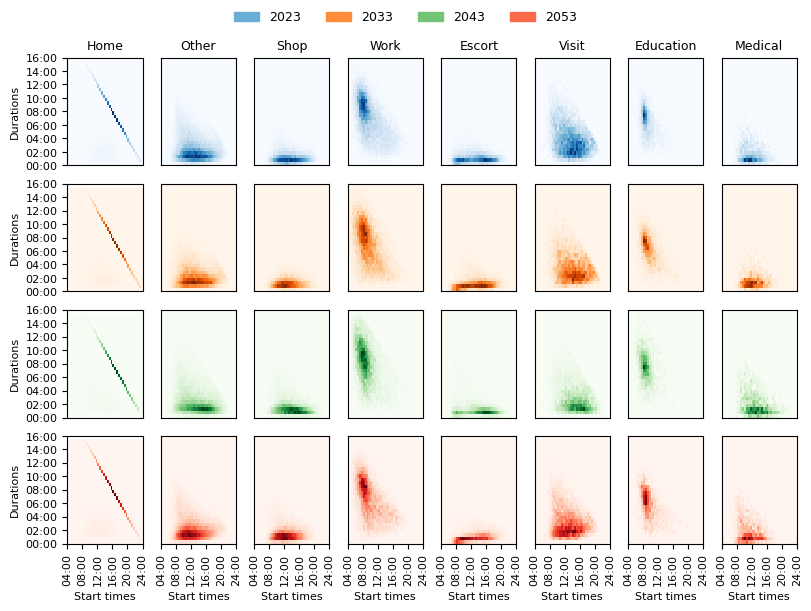

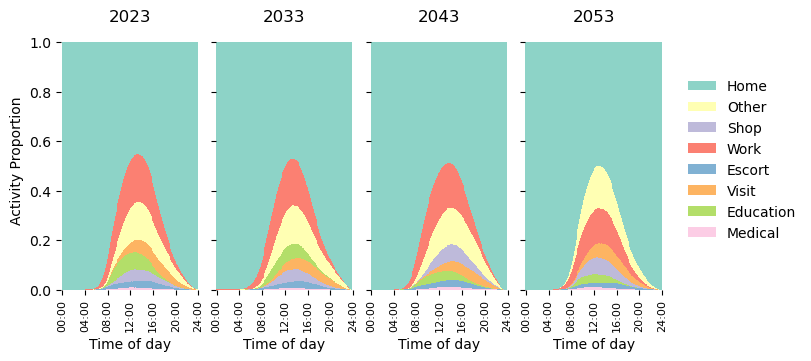

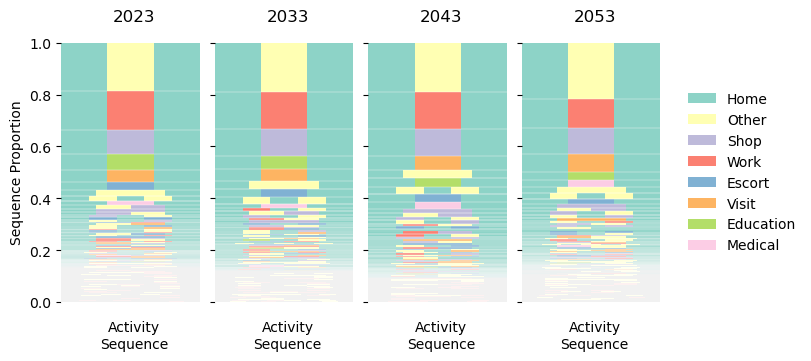

In [ ]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmap, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmap, figsize=(8, 3.5)
)

In [ ]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrr}
\toprule
 & s200 & s100 & s50 & s25 & s12 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.084 & 0.080 & 0.089 & 0.151 & 0.197 \\
transitions & 0.008 & 0.008 & 0.010 & 0.010 & 0.021 \\
timing & 0.030 & 0.030 & 0.039 & 0.049 & 0.068 \\
feasibility & 0.011 & 0.010 & 0.022 & 0.040 & 0.108 \\
creativity & 0.008 & 0.005 & 0.002 & 0.002 & 0.002 \\
\bottomrule
\end{tabular}



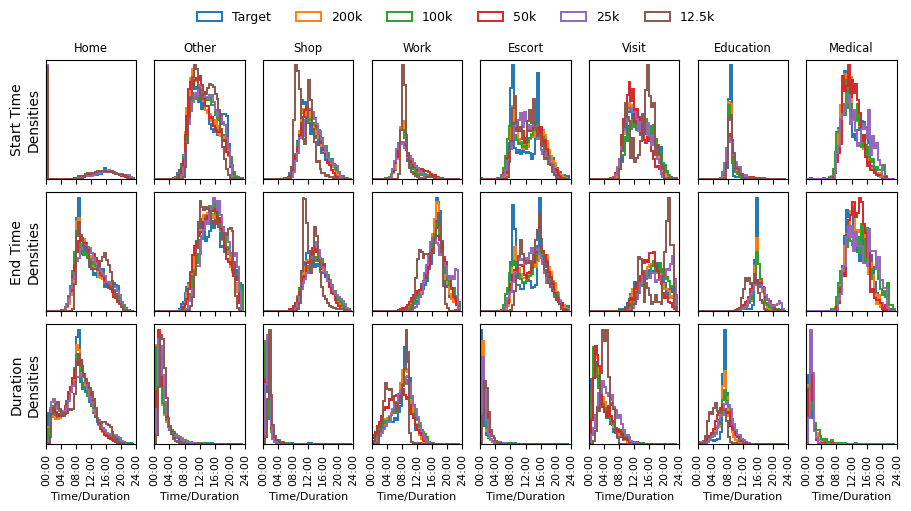

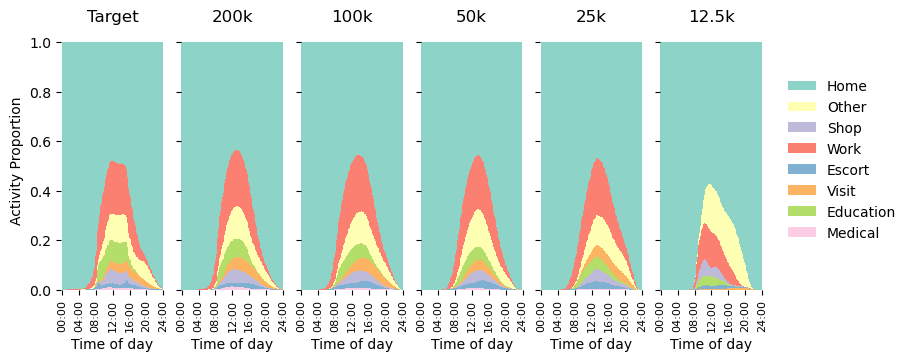

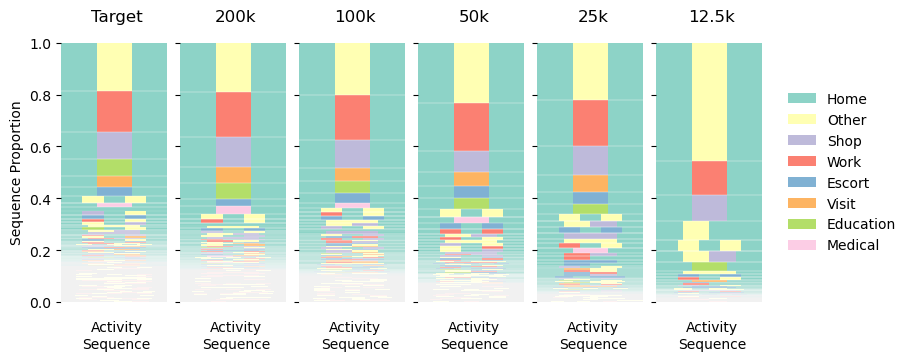

In [ ]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [ ]:
# # labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.054 & 0.057 & 0.057 & 0.082 & 0.095 \\
transitions & 0.003 & 0.005 & 0.003 & 0.005 & 0.003 \\
timing & 0.024 & 0.026 & 0.031 & 0.030 & 0.034 \\
feasibility & 0.014 & 0.037 & 0.032 & 0.024 & 0.009 \\
creativity & 0.024 & 0.024 & 0.021 & 0.017 & 0.017 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8,l16
domain,,,,,
creativity,0.024435,0.023776,0.020766,0.016546,0.017022
feasibility,0.014142,0.036758,0.032240,0.024471,0.008671
participations,0.053846,0.056799,0.056863,0.082038,0.095341
timing,0.024288,0.026039,0.030703,0.030038,0.033583
transitions,0.003493,0.005311,0.003229,0.005120,0.003324


In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.060 & 0.066 & 0.061 & 0.083 & 0.105 \\
transitions & 0.005 & 0.006 & 0.004 & 0.006 & 0.005 \\
timing & 0.026 & 0.029 & 0.032 & 0.032 & 0.035 \\
feasibility & 0.014 & 0.037 & 0.032 & 0.024 & 0.009 \\
creativity & 0.021 & 0.020 & 0.016 & 0.013 & 0.012 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8
domain,,,,
creativity,0.020729,0.019912,0.015650,0.012537
feasibility,0.014095,0.036662,0.032117,0.024398
participations,0.059690,0.065520,0.060706,0.083230
timing,0.026470,0.028956,0.032429,0.031748
transitions,0.004730,0.006452,0.004123,0.005961


In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

observed        l1        l2        l4        l8
domain         cat                                                         
creativity     employed    0.856972  0.983364  0.983169  0.985587  0.988441
               unemployed  0.828239  0.973999  0.975970  0.982296  0.985900
feasibility    employed    0.000000  0.005289  0.013351  0.016302  0.010590
               unemployed  0.000000  0.005360  0.014716  0.007735  0.007757
participations employed    0.210674  0.203601  0.201544  0.204747  0.201680
               unemployed  0.202714  0.197887  0.202357  0.197503  0.200837
timing         employed    0.453887  0.462139  0.460808  0.462901  0.462213
               unemployed  0.447872  0.458653  0.452141  0.458111  0.453287
transitions    employed    0.007494  0.012631  0.018294  0.013983  0.013391
               unemployed  0.008813  0.012343  0.018709  0.013162  0.013693

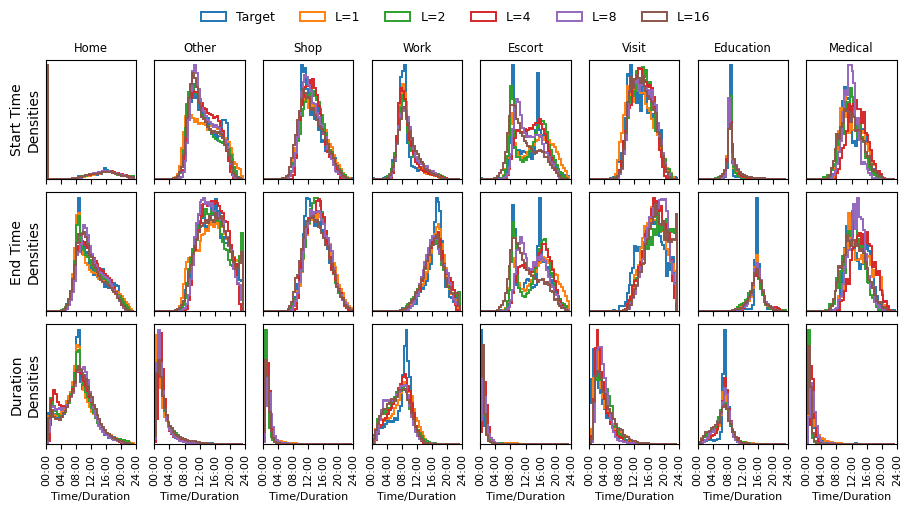

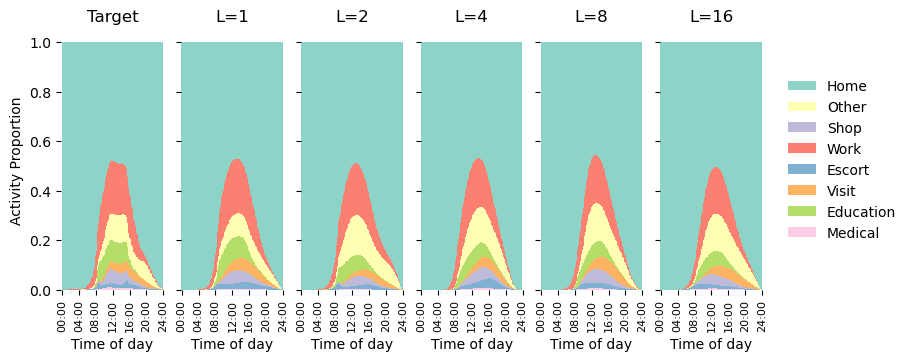

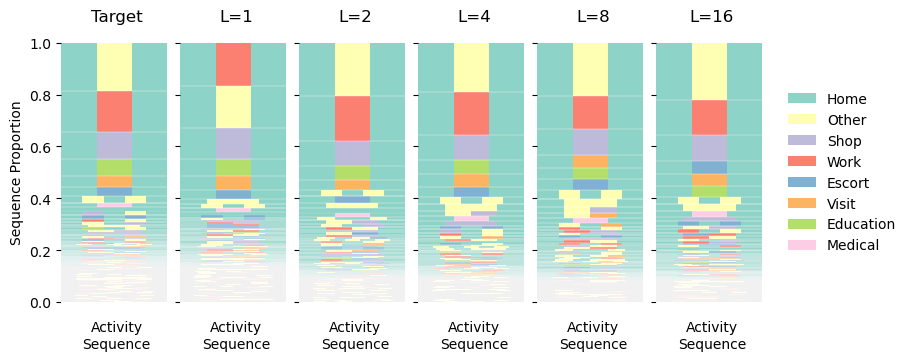

In [ ]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [ ]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances_subs.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

\begin{tabular}{lrr}
\toprule
 & unconditioned & conditioned \\
domain &  &  \\
\midrule
participations & 0.043 & 0.031 \\
transitions & 0.002 & 0.002 \\
timing & 0.018 & 0.014 \\
feasibility & 0.012 & 0.007 \\
creativity & 0.031 & 0.036 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrr}
\toprule
 & unconditioned & conditioned \\
domain &  &  \\
\midrule
participations & 0.050 & 0.046 \\
transitions & 0.003 & 0.002 \\
timing & 0.019 & 0.016 \\
feasibility & 0.011 & 0.007 \\
creativity & 0.020 & 0.023 \\
\bottomrule
\end{tabular}



,conditioned,unconditioned
domain,,
creativity,0.023274,0.019965
feasibility,0.006774,0.011481
participations,0.045715,0.049884
timing,0.015865,0.019459
transitions,0.002172,0.002636


In [ ]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

aggregate


KeyError: 'aggregate'

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]